# Tugas 1C - TF-IDF pada Artikel Berita

**Author:** Muhammad Razan Parisya Putra  
**Notebook:** `Tugas 1C - TF-IDF Artikel News`

---

## Objective

Menerapkan TF-IDF pada sebuah artikel berita berbahasa Indonesia untuk memahami
bagaimana TF-IDF mengekstrak kata-kata penting dari sebuah dokumen tunggal.

**Sumber artikel:**  
[BBC Indonesia - China peringatkan negara yang buat kesepakatan dengan AS](https://www.bbc.com/indonesia/articles/c1wdzeyr9wyo)

Artikel ini membahas perang dagang AS-China dan dampaknya terhadap negara-negara lain
termasuk Indonesia, Jepang, Korea Selatan, dan India.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Artikel

Artikel diambil dari BBC Indonesia, dipecah menjadi paragraf-paragraf sebagai "dokumen" individual.
Setiap paragraf menjadi satu dokumen dalam corpus, sehingga TF-IDF bisa menghitung
bobot kata relatif antar paragraf.

In [2]:
# Artikel: BBC Indonesia - China peringatkan negara yang buat kesepakatan dengan AS
# Sumber: https://www.bbc.com/indonesia/articles/c1wdzeyr9wyo

article_text = """
China memperingatkan bakal membalas negara-negara yang membuat kesepakatan dengan AS dan merugikan kepentingan Beijing. Perang dagang antara dua negara raksasa yang sedang terjadi saat ini bisa menjadi ancaman negara-negara lain.
Tanggapan ini menyusul adanya laporan bahwa AS berencana menekan negara lain untuk membatasi perdagangan dengan China sebagai imbalan dari kebijakan pajak impor.
Pemerintahan Trump mulai mengadakan pembicaraan dengan mitra dagangnya termasuk Indonesia mengenai kebijakan tarif pajak impor AS yang kontroversial.
Delegasi Jepang mengunjungi Washington minggu lalu, dan Korea Selatan akan mulai bernegosiasi pekan ini.
Pekan lalu, Indonesia secara resmi menawarkan akan membeli lebih banyak produk energi dan agrikultur dari AS.
Langkah ini diambil agar AS tidak mengenakan tarif tinggi impor dari Indonesia. Namun, otoritas Indonesia tidak menyinggung kaitannya dengan China.
Sejak kembali ke Gedung Putih pada Januari, Trump telah memberlakukan pajak yang cukup besar pada impor China.
Bukan hanya China, negara-negara lain juga kena kenaikan pungutan pada barang-barang yang masuk ke AS.
Menghibur tidak dapat membawa perdamaian, dan kompromi tidak dapat menghasilkan rasa hormat, ujar juru bicara Kementerian Perdagangan China.
China dengan tegas menentang pihak mana pun yang mencapai kesepakatan dengan mengorbankan kepentingan China. Jika hal ini terjadi, China tidak akan pernah menerimanya dan dengan tegas akan mengambil tindakan balasan.
Tanggapan ini menyusul adanya laporan bahwa AS berencana menggunakan negosiasi tarif untuk menekan puluhan negara memberlakukan hambatan baru dalam perdagangan dengan China.
Trump mengatakan lebih dari 70 negara telah menghubunginya untuk memulai negosiasi sejak kebijakan anyar tarif resiprokal diumumkan.
Jika Anda menghitungnya, sekitar 20 persen profitabilitas Jepang berasal dari Amerika Serikat, sekitar 15 persen berasal dari China, kata Jesper Koll dari Monex Group.
Tentu saja, Jepang tidak ingin harus memilih antara Amerika dan China.
Jepang memulai negosiasi dengan AS pekan lalu saat negosiator utamanya Ryosei Akazawa bertemu dengan Presiden AS di Washington DC.
Pelaksana tugas presiden Korea Selatan Han Duck-soo mengatakan negaranya akan memulai pembicaraan perdagangan dengan AS pada akhir pekan ini.
Sementara itu, Wakil Presiden AS JD Vance diperkirakan akan bertemu dengan Perdana Menteri India Narendra Modi dalam kunjungannya ke negara tersebut pekan ini.
India menghadapi tarif sebesar 26 persen jika tidak menyetujui kesepakatan perdagangan dengan pemerintahan Trump.
Kementerian Perdagangan Indonesia buka suara terkait peringatan China terhadap negara-negara yang tengah melakukan negosiasi kebijakan tarif dengan AS.
Djatmiko Bris Witjaksono meyakini China sama seperti Indonesia menjunjung tinggi prinsip-prinsip perdagangan multilateral dan kita saling menghormati hak dan kewajiban masing-masing.
Indonesia akan tetap memastikan bahwa kegiatan perdagangan dengan mitra dagang kita tetap dijalankan dengan sebaik-baiknya.
Kita tetap melakukan kegiatan perdagangan dengan mitra-mitra kita lainnya seperti biasa yang kita lakukan. Jadi kita tidak melakukan tindakan balasan.
Airlangga Hartarto mengatakan pemerintah Indonesia secara resmi menawarkan peningkatan pembelian produk energi dan agrikultur dari Amerika Serikat.
Indonesia akan membeli produk energi dari AS seperti LPG, kemudian US crude oil minyak mentah, dan gasoline bensin.
Juga Indonesia berencana untuk terus membeli produk agrikultur antara lain gandum, soya bean kedelai, soya bean milk susu kedelai, dan juga Indonesia akan meningkatkan pembelian barang-barang modal dari Amerika.
Trump bilang pajak impor akan mendorong konsumen AS untuk membeli lebih banyak barang buatan Amerika, meningkatkan jumlah pajak yang terkumpul, dan mendorong investasi besar-besaran di negara ini.
Para kritikus mengatakan membawa manufaktur kembali ke AS itu rumit dan dapat memakan waktu puluhan tahun.
Hanya beberapa jam pengumuman akan mengenakan pajak impor tinggi terhadap puluhan negara mitra dagang Amerika yang berlaku awal bulan ini, Trump mengumumkan melakukan penangguhan selama 90 hari.
Trump telah memberlakukan pajak hingga 145 persen untuk impor dari China. Negara-negara lain sekarang menghadapi tarif AS sebesar 10 persen hingga Juli.
China telah membalas dengan pajak 125 persen untuk produk-produk dari AS dan bersumpah untuk berjuang sampai akhir.
Perang dagang antara dua negara dengan perekonomian terbesar di dunia ini telah mengirimkan gelombang kejut ke seluruh pasar keuangan global pada awal bulan ini.
"""

# Pecah artikel menjadi paragraf (setiap baris = 1 dokumen)
paragraphs = [p.strip() for p in article_text.strip().split('\n') if p.strip()]

print(f'Jumlah paragraf (dokumen): {len(paragraphs)}')
print()
for i, p in enumerate(paragraphs[:5]):
    print(f'  [{i}] {p[:80]}...')

Jumlah paragraf (dokumen): 31

  [0] China memperingatkan bakal membalas negara-negara yang membuat kesepakatan denga...
  [1] Tanggapan ini menyusul adanya laporan bahwa AS berencana menekan negara lain unt...
  [2] Pemerintahan Trump mulai mengadakan pembicaraan dengan mitra dagangnya termasuk ...
  [3] Delegasi Jepang mengunjungi Washington minggu lalu, dan Korea Selatan akan mulai...
  [4] Pekan lalu, Indonesia secara resmi menawarkan akan membeli lebih banyak produk e...


## 3. Preprocessing Sederhana

In [3]:
def simple_preprocess(text):
    """Preprocessing sederhana untuk artikel berita."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)       # hapus angka dan tanda baca
    text = re.sub(r'\s+', ' ', text).strip()   # hapus whitespace berlebih
    return text

paragraphs_clean = [simple_preprocess(p) for p in paragraphs]

print('Contoh sebelum dan sesudah preprocessing:')
print(f'  BEFORE: {paragraphs[0][:80]}...')
print(f'  AFTER : {paragraphs_clean[0][:80]}...')

Contoh sebelum dan sesudah preprocessing:
  BEFORE: China memperingatkan bakal membalas negara-negara yang membuat kesepakatan denga...
  AFTER : china memperingatkan bakal membalas negaranegara yang membuat kesepakatan dengan...


## 4. Bag of Words (CountVectorizer)

Langkah pertama: ubah teks menjadi matriks frekuensi kata mentah.

In [4]:
# BoW
bow_vec = CountVectorizer()
bow_matrix = bow_vec.fit_transform(paragraphs_clean)

vocab = bow_vec.get_feature_names_out()

print(f'BoW Matrix   : {bow_matrix.shape}  (paragraf x kata unik)')
print(f'Vocabulary   : {len(vocab)} kata unik')

# Top 15 kata paling sering (frekuensi mentah)
freq = np.asarray(bow_matrix.sum(axis=0)).flatten()
top15 = freq.argsort()[::-1][:15]

print(f'\nTop 15 kata (BoW - frekuensi mentah):')
for idx in top15:
    print(f'  {vocab[idx]:20s} -> {int(freq[idx])}')

BoW Matrix   : (31, 289)  (paragraf x kata unik)
Vocabulary   : 289 kata unik

Top 15 kata (BoW - frekuensi mentah):
  dengan               -> 19
  as                   -> 17
  china                -> 16
  dan                  -> 14
  ini                  -> 12
  dari                 -> 12
  indonesia            -> 11
  akan                 -> 11
  yang                 -> 10
  perdagangan          -> 9
  untuk                -> 8
  negara               -> 8
  pajak                -> 8
  tidak                -> 8
  tarif                -> 7


## 5. TF-IDF (TfidfTransformer)

Langkah kedua: terapkan bobot IDF di atas matriks BoW.
Kata umum (muncul di banyak paragraf) bobotnya turun,
kata spesifik (khas satu paragraf) bobotnya naik.

In [5]:
# TF-IDF
tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(bow_matrix)

print(f'TF-IDF Matrix: {tfidf_matrix.shape}')

# Top 15 kata berdasarkan rata-rata TF-IDF score
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top15_tfidf = mean_tfidf.argsort()[::-1][:15]

print(f'\nTop 15 kata (TF-IDF - rata-rata bobot):')
for idx in top15_tfidf:
    print(f'  {vocab[idx]:20s} -> {mean_tfidf[idx]:.4f}')

TF-IDF Matrix: (31, 289)

Top 15 kata (TF-IDF - rata-rata bobot):
  dengan               -> 0.0728
  as                   -> 0.0660
  china                -> 0.0629
  dan                  -> 0.0586
  dari                 -> 0.0558
  indonesia            -> 0.0548
  ini                  -> 0.0510
  akan                 -> 0.0495
  tidak                -> 0.0467
  perdagangan          -> 0.0461
  yang                 -> 0.0460
  untuk                -> 0.0444
  pajak                -> 0.0433
  tarif                -> 0.0423
  trump                -> 0.0402


## 6. Perbandingan BoW vs TF-IDF

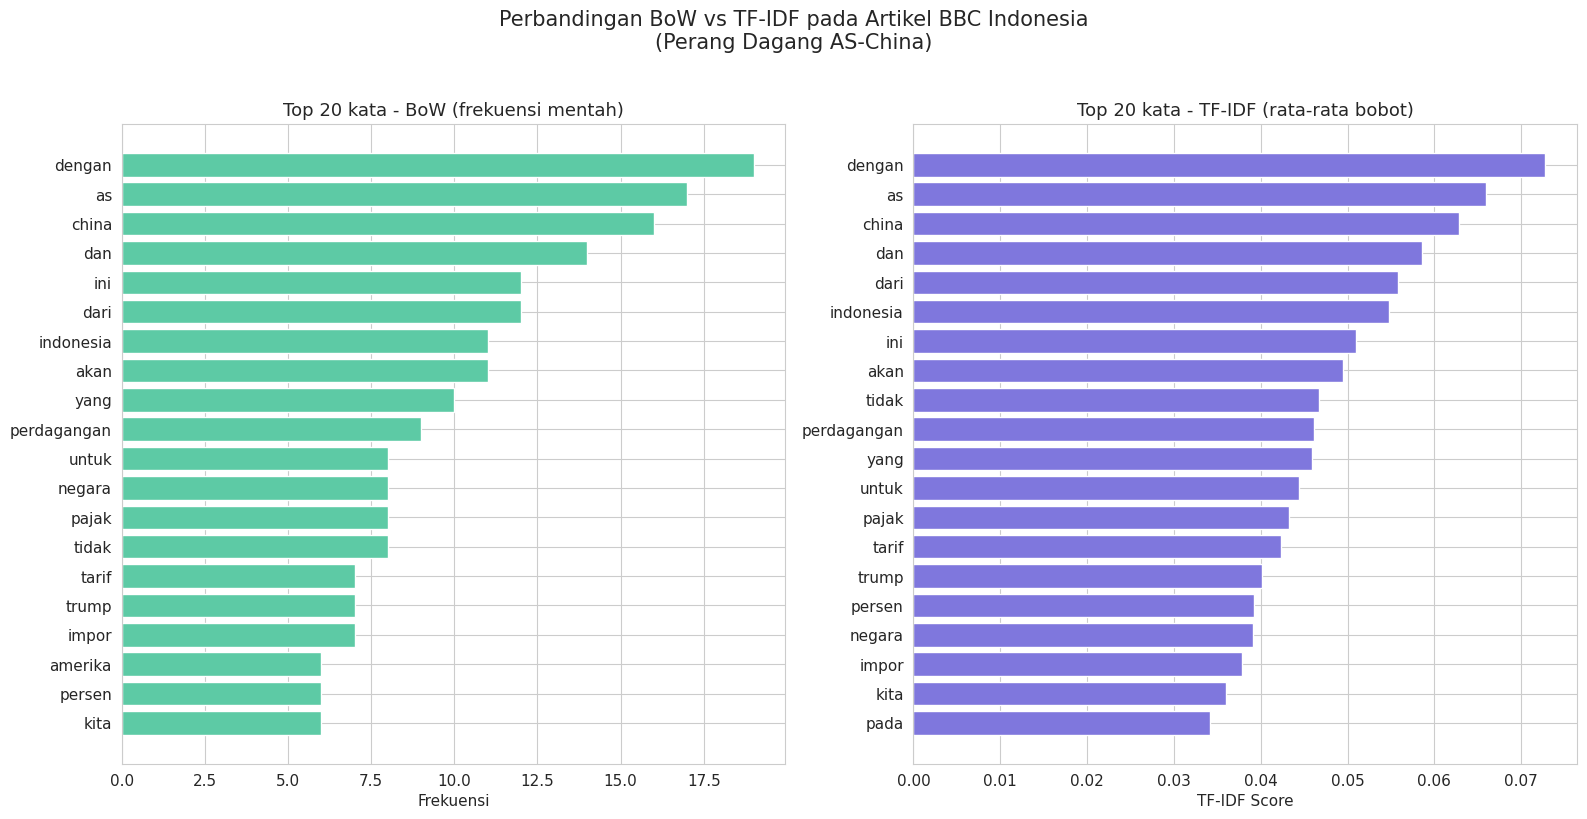

In [6]:
# Visualisasi perbandingan top 20 kata
top20_bow = freq.argsort()[::-1][:20]
top20_tfidf = mean_tfidf.argsort()[::-1][:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# BoW
words_b = [vocab[i] for i in top20_bow]
counts_b = [int(freq[i]) for i in top20_bow]
axes[0].barh(words_b[::-1], counts_b[::-1], color='#5DCAA5', edgecolor='white')
axes[0].set_title('Top 20 kata - BoW (frekuensi mentah)', fontsize=13)
axes[0].set_xlabel('Frekuensi')

# TF-IDF
words_t = [vocab[i] for i in top20_tfidf]
scores_t = [mean_tfidf[i] for i in top20_tfidf]
axes[1].barh(words_t[::-1], scores_t[::-1], color='#7F77DD', edgecolor='white')
axes[1].set_title('Top 20 kata - TF-IDF (rata-rata bobot)', fontsize=13)
axes[1].set_xlabel('TF-IDF Score')

plt.suptitle('Perbandingan BoW vs TF-IDF pada Artikel BBC Indonesia\n(Perang Dagang AS-China)',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Tabel perbandingan side-by-side
print(f'{"Rank":>4}  {"BoW (kata)":20s} {"Freq":>5}  |  {"TF-IDF (kata)":20s} {"Score":>8}')
print('-' * 70)
for rank in range(15):
    b_idx = top20_bow[rank]
    t_idx = top20_tfidf[rank]
    print(f'{rank+1:>4}  {vocab[b_idx]:20s} {int(freq[b_idx]):>5}  |  {vocab[t_idx]:20s} {mean_tfidf[t_idx]:>8.4f}')

Rank  BoW (kata)            Freq  |  TF-IDF (kata)           Score
----------------------------------------------------------------------
   1  dengan                  19  |  dengan                 0.0728
   2  as                      17  |  as                     0.0660
   3  china                   16  |  china                  0.0629
   4  dan                     14  |  dan                    0.0586
   5  ini                     12  |  dari                   0.0558
   6  dari                    12  |  indonesia              0.0548
   7  indonesia               11  |  ini                    0.0510
   8  akan                    11  |  akan                   0.0495
   9  yang                    10  |  tidak                  0.0467
  10  perdagangan              9  |  perdagangan            0.0461
  11  untuk                    8  |  yang                   0.0460
  12  negara                   8  |  untuk                  0.0444
  13  pajak                    8  |  pajak                

## 7. Analisis per Paragraf

Lihat kata terpenting di setiap paragraf menurut TF-IDF.
Ini menunjukkan bagaimana TF-IDF mengidentifikasi topik unik tiap paragraf.

In [8]:
# Top 3 kata per paragraf berdasarkan TF-IDF
print('Kata terpenting per paragraf (TF-IDF):')
print('=' * 80)

for i in range(min(10, len(paragraphs))):
    row = np.asarray(tfidf_matrix[i].todense()).flatten()
    top3 = row.argsort()[::-1][:3]
    keywords = ', '.join([f'{vocab[idx]} ({row[idx]:.3f})' for idx in top3 if row[idx] > 0])
    print(f'  [{i:2d}] {paragraphs[i][:60]}...')
    print(f'       Keywords: {keywords}')
    print()

Kata terpenting per paragraf (TF-IDF):
  [ 0] China memperingatkan bakal membalas negara-negara yang membu...
       Keywords: negaranegara (0.322), yang (0.243), beijing (0.212)

  [ 1] Tanggapan ini menyusul adanya laporan bahwa AS berencana men...
       Keywords: sebagai (0.283), membatasi (0.283), imbalan (0.283)

  [ 2] Pemerintahan Trump mulai mengadakan pembicaraan dengan mitra...
       Keywords: mengenai (0.298), mengadakan (0.298), kontroversial (0.298)

  [ 3] Delegasi Jepang mengunjungi Washington minggu lalu, dan Kore...
       Keywords: minggu (0.320), bernegosiasi (0.320), mengunjungi (0.320)

  [ 4] Pekan lalu, Indonesia secara resmi menawarkan akan membeli l...
       Keywords: secara (0.300), resmi (0.300), banyak (0.300)

  [ 5] Langkah ini diambil agar AS tidak mengenakan tarif tinggi im...
       Keywords: tidak (0.363), indonesia (0.312), namun (0.272)

  [ 6] Sejak kembali ke Gedung Putih pada Januari, Trump telah memb...
       Keywords: pada (0.432), cukup (0.

## 8. Kesimpulan

Dari analisis TF-IDF pada artikel BBC Indonesia tentang perang dagang AS-China:

- **BoW** menunjukkan kata-kata yang paling sering muncul secara keseluruhan (seperti "china", "as", "indonesia", "tarif"). Kata-kata umum mendominasi.
- **TF-IDF** memberikan bobot lebih tinggi pada kata-kata yang spesifik dan informatif per paragraf, seperti nama negara tertentu, angka tarif, atau istilah kebijakan.
- TF-IDF berhasil mengidentifikasi topik unik tiap paragraf: paragraf tentang Jepang menghasilkan kata kunci "jepang", paragraf tentang Indonesia menghasilkan "energi", "agrikultur", dst.

Ini mendemonstrasikan kekuatan TF-IDF dibandingkan BoW dalam mengekstrak kata-kata yang benar-benar bermakna dari sebuah teks.